# Práctica 1: Disección de la Imagen Digital

**Objetivo:** Manipular la estructura interna de una imagen. Entenderemos qué es un píxel, un canal y el peligroso tipo de dato `uint8`.

## 1. Configuración del Entorno
Importamos las librerías.
* **NumPy:** Será nuestro bisturí para operar la matriz.
* **Matplotlib:** Será nuestro microscopio para ver los resultados.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Esto hace que las gráficas se vean integradas y grandes
%matplotlib inline
plt.rcParams['figure.figsize'] = [8, 8]

## 2. Carga y Primera Inspección
Tu primera misión es cargar una imagen y entender qué ha pasado en la memoria RAM.
* **Nota:** Usa la función `read` adecuada de matplotlib (`plt`).
* **Reto:** Matplotlib a veces lee imágenes como `float` (0.0 a 1.0) y otras como `int` (0 a 255). Vamos a averiguarlo.

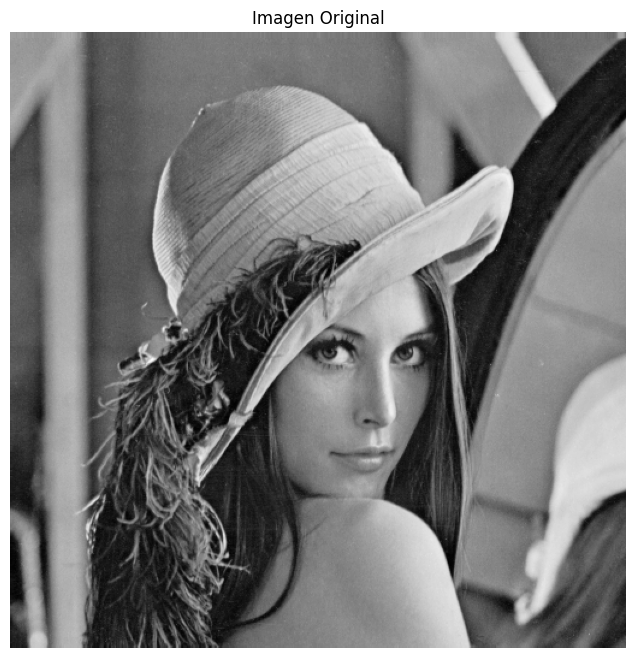

--- DATOS DE LA AUTOPSIA ---
Tipo de variable: <class 'numpy.ndarray'>
Tipo de dato del píxel (dtype): float32
Dimensiones (Shape): (512, 512)
Intensidad Máxima: 0.9607843160629272
Intensidad Mínima: 0.09803921729326248


In [3]:
# 1. Carga la imagen 'images/lenna_gris.png' (o la que tengas disponible)
imagen = plt.imread("images/lenna_gris.png")

# 2. Muestrala por pantalla
# IMPORTANTE: Al ser una imagen de un solo canal, si no especificas el 'cmap' (mapa de color),
# matplotlib le pondrá colores falsos. Nosotros queremos verla en BLANCO Y NEGRO real.
plt.imshow(imagen, cmap='gray')
plt.title("Imagen Original")
plt.axis('off') # Quitamos los ejes numéricos
plt.show()

# 3. Inspección Forense
print("--- DATOS DE LA AUTOPSIA ---")
print(f"Tipo de variable: {type(imagen)}")
print(f"Tipo de dato del píxel (dtype): {imagen.dtype}") # ¿Es uint8 o float?
print(f"Dimensiones (Shape): {imagen.shape}")
print(f"Intensidad Máxima: {imagen.max()}")
print(f"Intensidad Mínima: {imagen.min()}")

> **Pregunta de reflexión:** Si la propiedad `.shape` te devuelve `(1080, 1920)`, ¿cuál es la altura y cuál es la anchura? ¿Por qué NumPy lo ordena así?
>
> *Respuesta:* 1080 es la altura y 1920 la anchura. NumPy lo ordena así porque en informática el eje 0 es el vertical y el eje 1 es el horizontal.

## 3. El Sistema de Coordenadas y "Slicing"
En visión artificial, el eje de coordenadas $(0,0)$ está en la **esquina superior izquierda**.
Vamos a practicar el *Slicing* (recorte) inteligente.

**Objetivo:** Crear un efecto de "Persiana". Queremos poner **negras** (valor 0) todas las **filas pares** de la imagen.

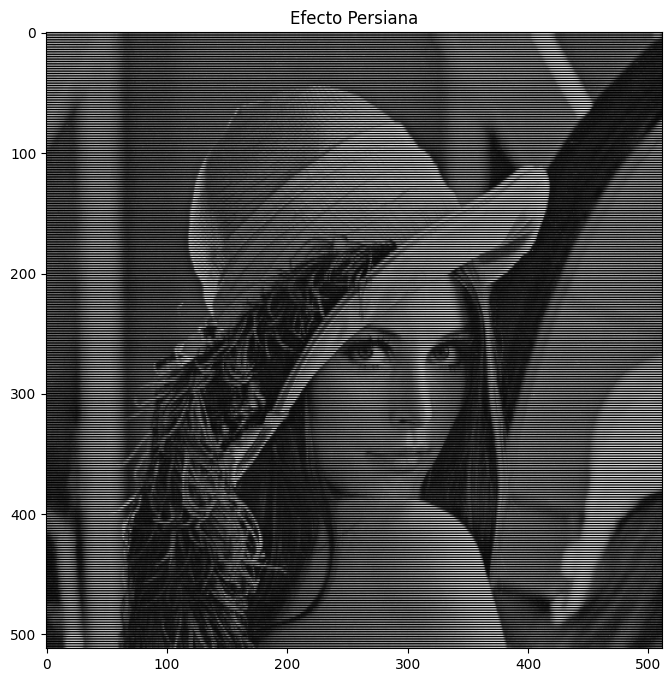

In [4]:
# Hacemos una copia para no romper la original
imagen_persiana = imagen.copy()

# SINTAXIS DE SLICING EN NUMPY:
# imagen[ inicio:fin:paso , inicio:fin:paso ]
#         ^ FILAS (Eje 0)     ^ COLUMNAS (Eje 1)

# Rellena los huecos del corchete:
# 1. Queremos empezar en la fila 0.
# 2. Ir hasta la última fila (déjalo vacío o usa None).
# 3. Saltar de 2 en 2.
# 4. Queremos afectar a TODAS las columnas (:).

# Rellena aquí los huecos (___):
imagen_persiana[0::2,:] = 0

plt.imshow(imagen_persiana, cmap='gray')
plt.title("Efecto Persiana")
plt.show()

## 4. Muestreo (Sampling) - "Pixel Art"
En teoría vimos que el **muestreo** define la resolución. Vamos a reducir la resolución de la imagen artificialmente quedándonos solo con 1 de cada 10 píxeles.

Nuevas dimensiones: (52, 52)


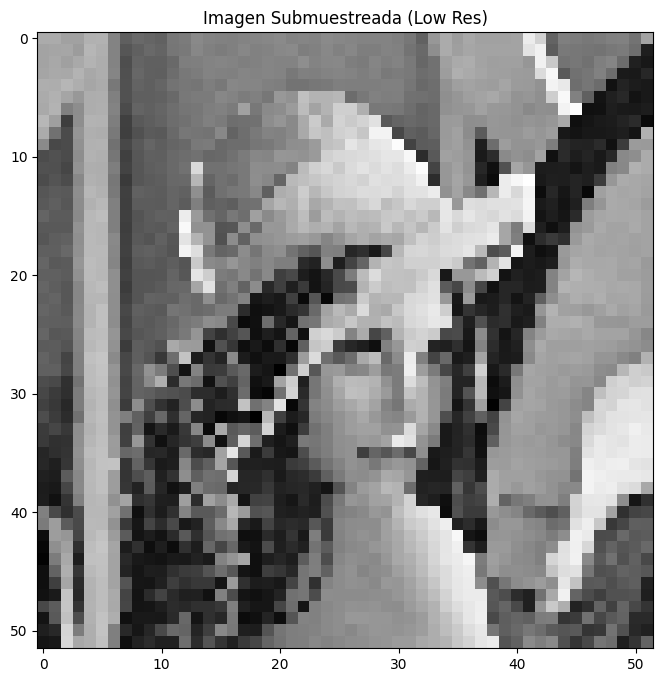

In [5]:
# RETO: Usa slicing para quedarte con un píxel de cada 10, tanto en filas como en columnas.
# PISTA: Usa el tercer parámetro del slicing (el paso o 'step').

imagen_pixelada = imagen[0::10, 0::10]

print(f"Nuevas dimensiones: {imagen_pixelada.shape}")
plt.imshow(imagen_pixelada, cmap='gray')
plt.title("Imagen Submuestreada (Low Res)")
plt.show()

## 5. Disección de Canales (Tensores 3D)
Carga ahora una imagen **A COLOR** (`images/color_1280_720.jpg` o similar).
Una imagen a color es un cubo de datos `(Alto, Ancho, 3)`. Vamos a separar esos 3 canales.

**¡OJO!** Un canal separado (ej: solo el Rojo) deja de ser "rojo" visualmente. Se convierte en una matriz de intensidad (escala de grises) donde:
* Blanco (255) = Mucho color rojo.
* Negro (0) = Nada de color rojo.

Shape de imagen color: (720, 1280, 3)


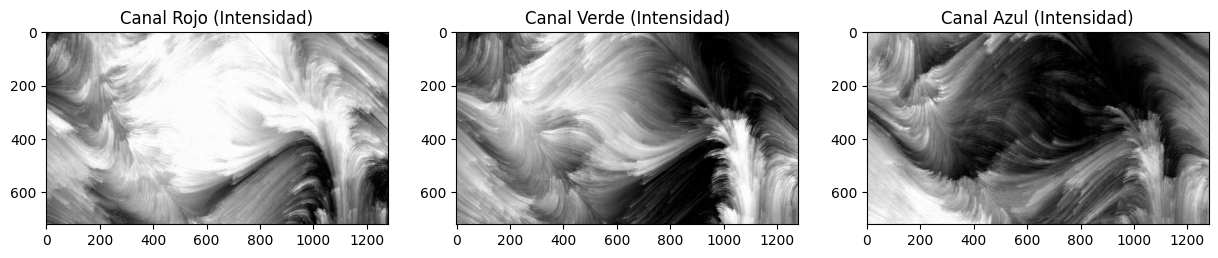

In [6]:
# 1. Cargar imagen color
img_color = plt.imread("images/color_1280_720.jpg")
print(f"Shape de imagen color: {img_color.shape}")

# 2. Separar canales
# NumPy indexa así: [Filas, Columnas, Canal]
# Canal 0: Rojo | Canal 1: Verde | Canal 2: Azul

canal_R = img_color[:, :, 0] # Rellena el índice
canal_G = img_color[:, :, 1] # Rellena el índice
canal_B = img_color[:, :, 2] # Rellena el índice

# 3. Visualizar
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# IMPORTANTE: Usamos cmap='gray' porque estamos viendo INTENSIDADES
ax1.imshow(canal_R, cmap='gray')
ax1.set_title("Canal Rojo (Intensidad)")

ax2.imshow(canal_G, cmap='gray')
ax2.set_title("Canal Verde (Intensidad)")

ax3.imshow(canal_B, cmap='gray')
ax3.set_title("Canal Azul (Intensidad)")

plt.show()

## 6. Algoritmo Manual: De Color a Grises (El Reto de Tipos)
Vas a implementar la conversión a blanco y negro manualmente.
La fórmula de la luminosidad (para que el ojo humano lo vea natural) es:
$$Gris = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$$

**PELIGRO:** Si multiplicas decimales (`0.299`) por enteros (`uint8`), Python cambiará el tipo a `float64`. Si luego intentas guardar eso como imagen sin volver a convertirlo, tendrás problemas.

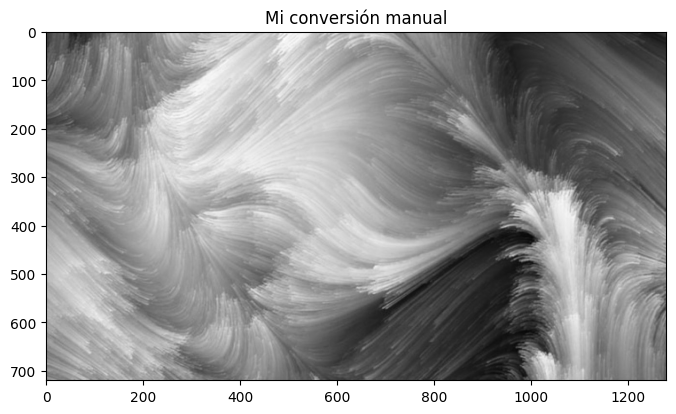

In [7]:
def color2gray_manual(imagen_rgb):
    # PASO 1: Conversión de seguridad
    # Convertimos la imagen a 'float' para poder multiplicar con decimales sin perder información
    # y para evitar desbordamientos prematuros.
    # Rellena el tipo de dato entre comillas (ej: 'float' o 'int')
    img_float = imagen_rgb.astype("float")
    
    # PASO 2: Extraer canales (usando la variable float que acabas de crear)
    r = img_float[:, :, 0]
    g = img_float[:, :, 1]
    b = img_float[:, :, 2]
    
    # PASO 3: Aplicar la fórmula
    # Multiplica cada canal por su peso y súmalos
    gris = (0.299 * r) + (0.587 * g) + (0.114 * b)
    
    # PASO 4: Volver al mundo de las imágenes (Casteo)
    # La matriz 'gris' ahora mismo es de números decimales (floats).
    # Para que sea una imagen válida de 8 bits (0-255), debemos convertirla.
    # PISTA: El tipo de dato estándar para imágenes es 'uint8'
    return gris.astype('uint8')

# Probamos tu función
imagen_bn_manual = color2gray_manual(img_color)
plt.imshow(imagen_bn_manual, cmap='gray')
plt.title("Mi conversión manual")
plt.show()

## 7. El Misterio del "Overflow" (Desbordamiento)
Las imágenes `uint8` son cíclicas como un reloj.
* $255 + 1 = 0$
* $200 + 100 = 44$ (y no 300)

Vamos a provocar este error a propósito para que aprendas a reconocerlo cuando te pase en el futuro.

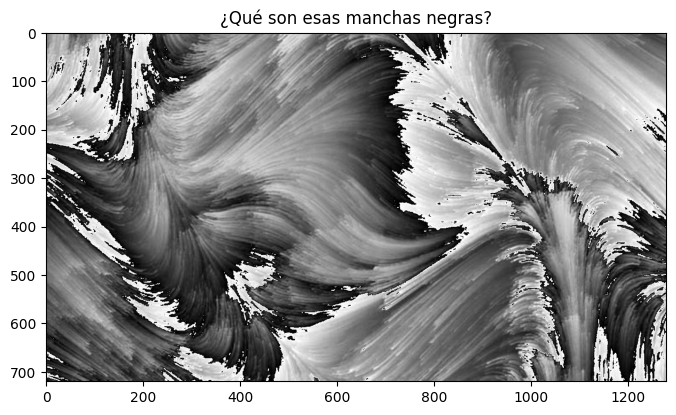

In [8]:
# 1. Cargamos dos imágenes (asegúrate de que sean del mismo tamaño o usa recortes)
# Usaremos la imagen B/N que creaste antes
img_A = imagen_bn_manual
img_B = imagen_bn_manual # Usamos la misma para sumarla consigo misma (doble de luz)

# 2. Vamos a sumar las imágenes directamente.
# Como son uint8, ocurrirá el desbordamiento en las zonas brillantes.
suma_desastrosa = img_A + img_B

# 3. Visualizamos
plt.imshow(suma_desastrosa, cmap='gray')
plt.title("¿Qué son esas manchas negras?")
plt.show()

**Ejercicio Final:**
Explica con tus palabras qué ha ocurrido en las zonas blancas de la foto (por ejemplo, en las nubes o brillos de la cara) y por qué se han vuelto negras.
> *Explicación:* Los valores que, al sumarle el mismo valor, han sobrepasado el valor 255 (por ejemplo, 200 + 200 = 400), la diferencia del resultado menos 255 pasa a sumarse desde el 0 (400 - 255 = 145. El valor no sería 400, sino 145).

---
# Retos Finales

### Reto 1: El Negativo Fotográfico
Invierte los colores de la imagen. Lo que es blanco (255) debe ser negro (0) y viceversa.
*Pista: Piensa en la aritmética. Si tengo 255 y quiero 0, y si tengo 0 quiero 255... ¿qué operación matemática básica necesito?*

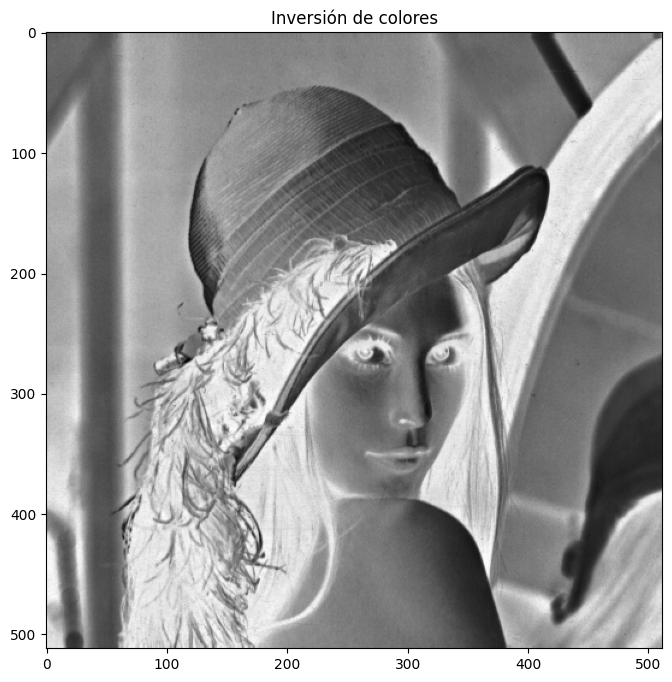

In [9]:
imagen_negativa = plt.imread("images/lenna_gris.png")
imagen_negativa = imagen_negativa.max() - imagen
plt.imshow(imagen_negativa, cmap='gray')
plt.title("Inversión de colores")
plt.show()

### Reto 2: El Espejo (Mirroring)
Voltea la imagen horizontalmente (efecto espejo) usando **solamente Slicing**.
*Pista: En Python, un slice tiene `[inicio : fin : paso]`. ¿Qué pasa si el paso es negativo?*

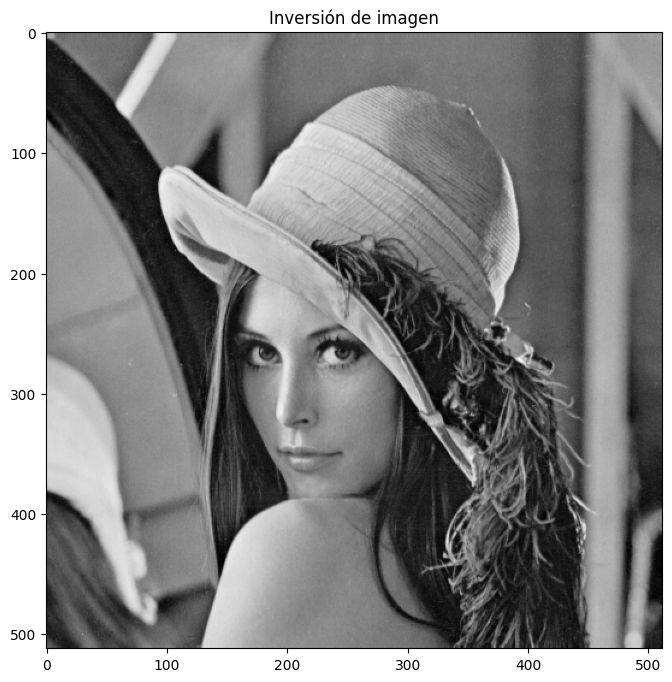

In [10]:
imagen_invertida = plt.imread("images/lenna_gris.png")
imagen_invertida = imagen_invertida[:,::-1]
plt.imshow(imagen_invertida, cmap='gray')
plt.title("Inversión de imagen")
plt.show()

### Reto 3: Efecto "Glitch" (Desplazamiento de Canal)
Coge la imagen a color. Mueve el **Canal Rojo** 20 píxeles a la derecha y el **Canal Azul** 20 píxeles a la izquierda.
*Nota:* Esto creará un efecto de aberración cromática como en las televisiones antiguas o el estilo Cyberpunk.
*Ayuda:* Probablemente necesites crear una imagen negra vacía (`np.zeros`) y pegar los trozos desplazados.

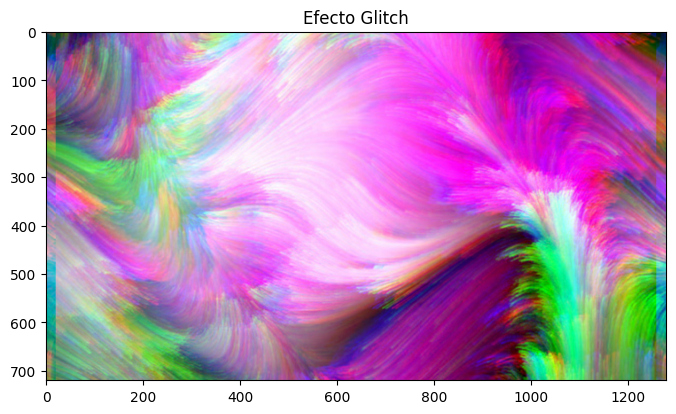

In [ ]:
imagen_rgb = plt.imread("images/color_1280_720.jpg")
imagen_negra = np.zeros_like(imagen_rgb)

# .roll mueve los elementos de un array x posiciones
r = np.roll(imagen_rgb[:, :, 0], 20, axis=1)
g = imagen_rgb[:, :, 1]
b = np.roll(imagen_rgb[:, :, 0], -20, axis=1)

imagen_negra[:, :, 0] = r
imagen_negra[:, :, 1] = g
imagen_negra[:, :, 2] = b

plt.imshow(imagen_negra, cmap='gray')
plt.title("Efecto Glitch")
plt.show()

### Reto 4 (opcional): Combinar imagenes
Usa la imagen de lena y de lena invertida y combínalas para crear una imagen donde las filas pares sean de lena y las impares de lena invertida.

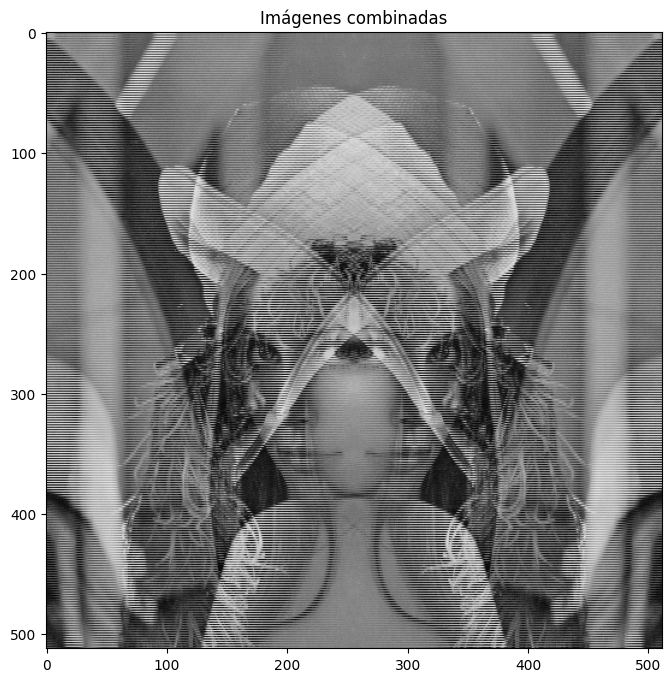

In [19]:
imagen_combinada = np.zeros_like(imagen)
imagen_combinada[0::2,:] = imagen[0::2,:]
imagen_combinada[1::2,:] = imagen_invertida[1::2,:]

plt.imshow(imagen_combinada, cmap='gray')
plt.title("Imágenes combinadas")
plt.show()